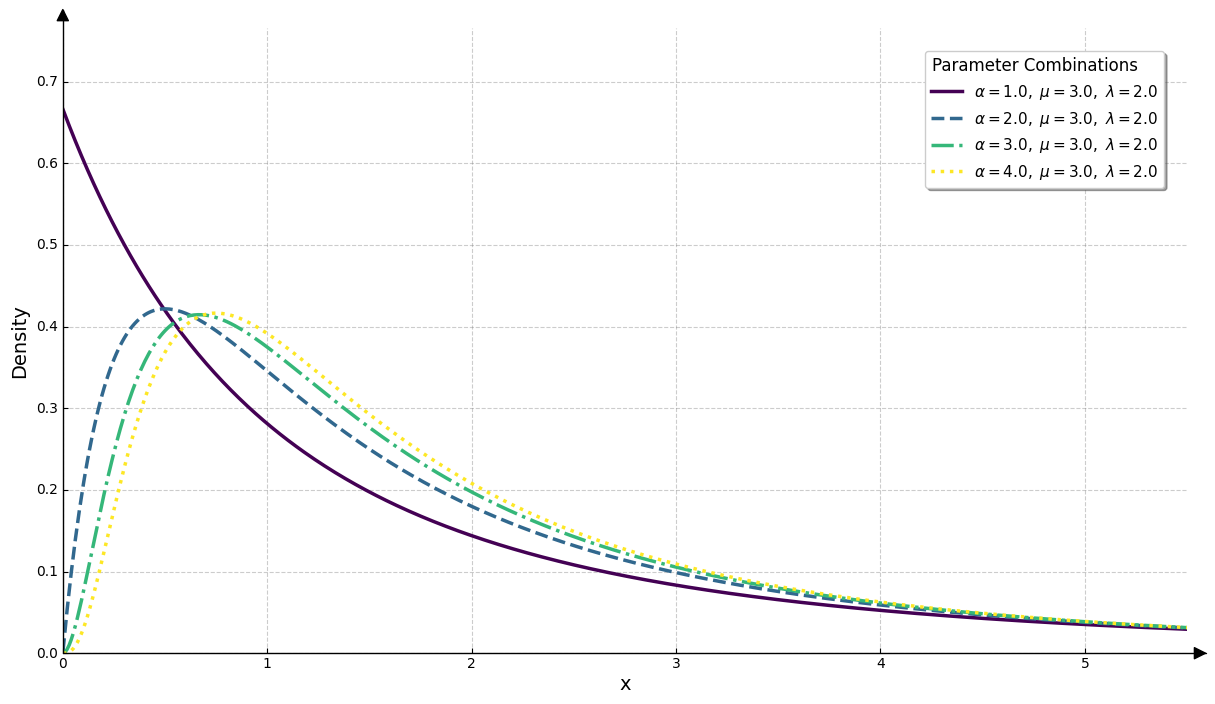

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import gamma, beta
from mpl_toolkits.axisartist.axislines import SubplotZero

# 定义密度函数
def custom_density(x, alpha, mu, lambd):
    term1 = alpha ** alpha * (lambd - 1) ** lambd * x ** (alpha - 1) / mu ** alpha
    term2 = gamma(alpha + lambd) / gamma(alpha) / gamma(lambd)
    term3 = (alpha * x / mu + lambd - 1) ** (-alpha - lambd)
    return term1 * term2 * term3

# 参数组合设置（可自由添加）
param_combinations = [
    {"alpha": 1.0, "mu": 3.0, "lambd": 2.0},
    {"alpha": 2.0, "mu": 3.0, "lambd": 2.0},
    {"alpha": 3.0, "mu": 3.0, "lambd": 2.0},
    {"alpha": 4.0, "mu": 3.0, "lambd": 2.0}
]

# 生成公共x轴数据
x = np.linspace(0.001, 10, 1000)

# 创建画布
fig = plt.figure(figsize=(12, 7), dpi=100)
ax = SubplotZero(fig, 111)
fig.add_subplot(ax)

# 设置专业坐标轴
for direction in ["left", "right", "top", "bottom"]:
    ax.axis[direction].set_visible(False)
xaxis = ax.axis["x"] = ax.new_floating_axis(0, 0)
yaxis = ax.axis["y"] = ax.new_floating_axis(1, 0)
xaxis.set_axisline_style("-|>", size=2.0)
yaxis.set_axisline_style("-|>", size=2.0)

# 设置标签方向
xaxis.set_ticklabel_direction("-")
yaxis.set_ticklabel_direction("-")
ax.axis["x"].set_axis_direction("bottom")
ax.axis["y"].set_axis_direction("left")

# 使用seaborn配色方案
colors = plt.cm.viridis(np.linspace(0, 1, len(param_combinations)))

line_styles = ['-', '--', '-.', ':']  # 修正线型定义

# 循环绘制各参数曲线
max_y = 0
for idx, params in enumerate(param_combinations):
    y = custom_density(x, **params)
    ax.plot(x, y, color=colors[idx], ls=line_styles[idx], lw=2.5, 
            label=fr"$\alpha={params['alpha']},\ \mu={params['mu']},\ \lambda={params['lambd']}$")
    max_y = max(max_y, y.max())

# 坐标轴范围设置
ax.set_xlim(0, 5.5)
ax.set_ylim(0, max_y * 1.15)

# 标签设置
ax.axis["x"].label.set_text("x")
ax.axis["y"].label.set_text("Density")
ax.axis["x"].label.set_fontsize(14)
ax.axis["y"].label.set_fontsize(14)

# 高级图例设置
legend = ax.legend(
    loc="upper right",
    fontsize=11,
    frameon=True,
    shadow=True,
    facecolor="white",
    borderaxespad=1.5,
    ncol=1,  # 分两列显示
    title="Parameter Combinations",
    title_fontsize=12
)
legend.get_title().set_position((-10, 0))  # 调整标题位置

# 网格线设置
ax.grid(True, linestyle='--', alpha=0.4, color="grey")

# 动态标题
# plt.title(r"Density of IGa-Ga$(\alpha,\mu,\lambda)$ distribution under various parameter combinations.",
#           fontsize=15, pad=25)

plt.tight_layout()
plt.savefig('plot1.png', dpi=800, bbox_inches='tight', pad_inches=0.1)
plt.show()

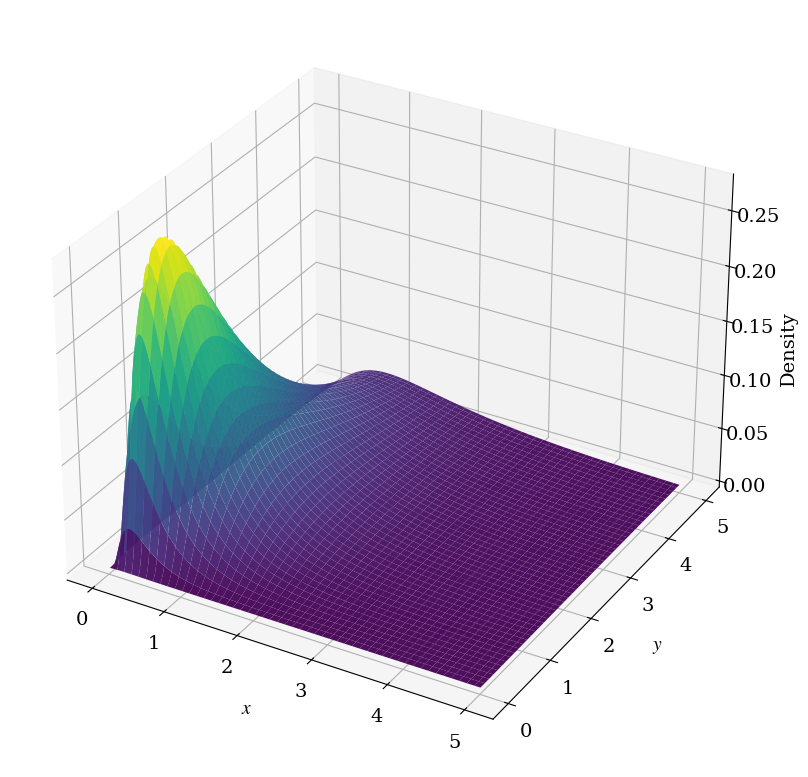

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import gamma  # 需要导入gamma函数

alp = 3.0
mu1 = 2.0
mu2 = 5.0
lam = 2.0

# ===========================
# 定义二维密度函数
# ===========================
def density(x, y):
    alpha_plus = 2 * alp
    
    C = (gamma(lam + alpha_plus) * (lam - 1)**lam) / gamma(lam)
    
    term1 = (alp ** alp * x ** (alp - 1)) / (gamma(alp) * mu1 ** alp)
    term2 = (alp ** alp * y ** (alp - 1)) / (gamma(alp) * mu2 ** alp)
    
    core = alp * x / mu1 + alp * y / mu2 + lam - 1
    
    return C * term1 * term2 * core ** (-(lam + alpha_plus))

# =========================
# 2. 构造网格
# =========================
x = np.linspace(0.01, 5, 200)
y = np.linspace(0.01, 5, 200)
X, Y = np.meshgrid(x, y)
Z = density(X, Y)

# =========================
# 3. 绘图
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 14
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 曲面图
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,
    edgecolor='none',
    antialiased=True,
    linewidth=0,
    alpha=0.95
)

# 坐标标签
ax.set_xlabel(r"$x$", labelpad=10)
ax.set_ylabel(r"$y$", labelpad=10)
ax.set_zlabel("", labelpad=20)

# 在 figure 级别使用 text 添加标签（使用相对坐标 0-1）
# 位置在右侧中间，旋转90度
fig.text(0.9, 0.55, 'Density', 
         ha='center', va='center', 
         rotation=90, 
         fontsize=14,
         fontfamily='serif')
ax.view_init(elev=30, azim=-60)

# 添加 colorbar
# fig.colorbar(surf, shrink=0.5, aspect=12, label='Density Value')

plt.tight_layout()
plt.savefig('plot2.png', dpi=800, bbox_inches='tight', pad_inches=0.1)
plt.show()

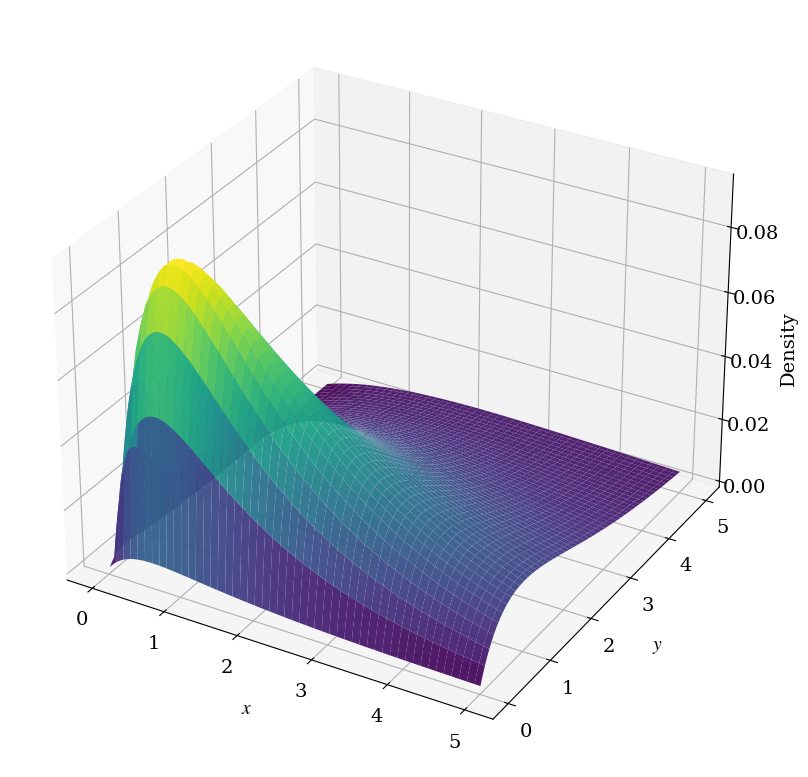

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.special import gamma, kv  # 需要导入gamma函数

alp = 2.0
mu1 = 5.0
mu2 = 3.0
lam = 2.0

# ===========================
# 定义二维密度函数
# ===========================
def density(x, y):
    a = lam * kv(1, lam) / kv(0, lam)
    b = lam * kv(0, lam) / kv(1, lam)
    z = a * (b + 2 * alp * (x / mu1 + y / mu2))

    term1 = (alp ** alp * x ** (alp - 1)) / (gamma(alp) * mu1 ** alp) * (alp ** alp * y ** (alp - 1)) / (gamma(alp) * mu2 ** alp)
    term2 = kv(2 * alp, np.sqrt(z)) / kv(0, lam)
    term3 = (a / (b + 2 * alp * (x / mu1 + y / mu2))) ** alp

    
    return term1 * term2 * term3

# =========================
# 2. 构造网格
# =========================
x = np.linspace(0.01, 5, 200)
y = np.linspace(0.01, 5, 200)
X, Y = np.meshgrid(x, y)
Z = density(X, Y)

# =========================
# 3. 绘图
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 14
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 曲面图
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,
    edgecolor='none',
    antialiased=True,
    linewidth=0,
    alpha=0.95
)

# 坐标标签
ax.set_xlabel(r"$x$", labelpad=10)
ax.set_ylabel(r"$y$", labelpad=10)
ax.set_zlabel("", labelpad=20)

# 在 figure 级别使用 text 添加标签（使用相对坐标 0-1）
# 位置在右侧中间，旋转90度
fig.text(0.9, 0.55, 'Density', 
         ha='center', va='center', 
         rotation=90, 
         fontsize=14,
         fontfamily='serif')
ax.view_init(elev=30, azim=-60)

# 添加 colorbar
# fig.colorbar(surf, shrink=0.5, aspect=12, label='Density Value')

plt.tight_layout()
plt.savefig('plot3.png', dpi=800, bbox_inches='tight', pad_inches=0.1)
plt.show()

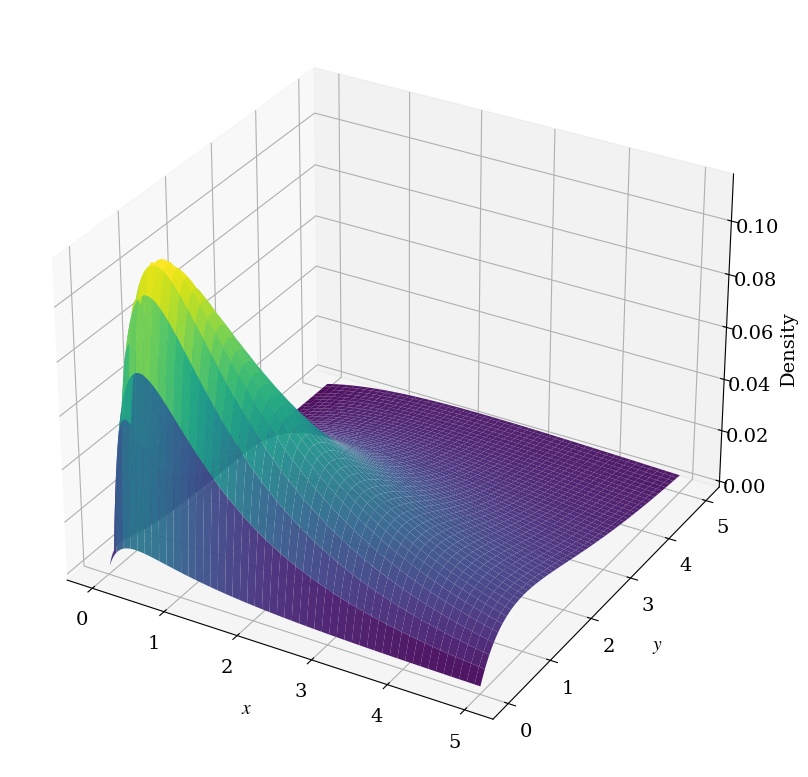

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
from scipy.integrate import quad
from scipy.special import gamma  # 需要导入gamma函数

alp = 2.0
mu1= 5.0
mu2 = 3.0
lam = 0.5

# ===========================
# 定义二维密度函数
# ==========================

# ==================================================
# 二维 LN-Ga 密度函数（严格按公式）
# ==================================================

def density(x1, x2, alp, mu1, mu2, lam):

    # -------- 常数部分 --------
    const = (
        1 / np.sqrt(2 * np.pi * lam)
        * (alp**alp * x1**(alp-1)) / (gamma(alp) * mu1**alp)
        * (alp**alp * x2**(alp-1)) / (gamma(alp) * mu2**alp)
    )

    # -------- 被积函数 --------
    def integrand(tau):
        return (
            tau**(-2*alp - 1)
            * np.exp(
                - alp*x1/(mu1*tau)
                - alp*x2/(mu2*tau)
                - (np.log(tau) + lam/2)**2 / (2*lam)
            )
        )

    # -------- 数值积分 --------
    val, _ = quad(integrand, 0, np.inf)

    return const * val
# =========================
# 2. 构造网格
# =========================
x = np.linspace(0.01, 5, 200)
y = np.linspace(0.01, 5, 200)
X, Y = np.meshgrid(x, y)
Z = np.zeros_like(X)

for i in range(len(x)):
    for j in range(len(y)):
        Z[i,j] = density(X[i,j], Y[i,j], alp, mu1, mu2, lam)

# =========================
# 3. 绘图
# =========================
plt.rcParams.update({
    "font.family": "serif",
    "mathtext.fontset": "stix",
    "font.size": 14
})

fig = plt.figure(figsize=(10, 8))
ax = fig.add_subplot(111, projection='3d')

# 曲面图
surf = ax.plot_surface(
    X, Y, Z,
    cmap=cm.viridis,
    edgecolor='none',
    antialiased=True,
    linewidth=0,
    alpha=0.95
)

# 坐标标签
ax.set_xlabel(r"$x$", labelpad=10)
ax.set_ylabel(r"$y$", labelpad=10)
ax.set_zlabel("", labelpad=20)

# 在 figure 级别使用 text 添加标签（使用相对坐标 0-1）
# 位置在右侧中间，旋转90度
fig.text(0.9, 0.55, 'Density', 
         ha='center', va='center', 
         rotation=90, 
         fontsize=14,
         fontfamily='serif')
ax.view_init(elev=30, azim=-60)

# 添加 colorbar
# fig.colorbar(surf, shrink=0.5, aspect=12, label='Density Value')

plt.tight_layout()
plt.savefig('plot4.png', dpi=800, bbox_inches='tight', pad_inches=0.1)
plt.show()